In [1]:
%matplotlib inline

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import sys
import pyreadstat
import requests
import time
import urllib.request
import os
import gtfs_kit as gk
import zipfile
import statsmodels

In [24]:
import json

In [179]:
import seaborn as sns

In [221]:
import numpy as np

## 1. Data Source Declaration

For the purposes of this project we are going to load two datasets. 

The first data set is the Netherlands National Travel Survey (ODiN - Onderweg in Nederland) for 2023 published by Statistics Netherlands. The dataset is provided by DANS Data Station and can be downloaded via the link: https://ssh.datastations.nl/dataset.xhtml?persistentId=doi:10.17026/SS/FNXJEU. ODiN is a continuous daily survey into the travel behaviour of residents of the Netherlands. Respondents are asked for one specific day of the year to record where they went, with what purpose, with what mode of transport and how long it took. The survey contains many individual trip microdata explaining the used transport mode, the purpose of the trip, the departure and arrival times, various socioeconomics, etc.  

Why we are going to load the data from 2023? The data for 2025 is still not available in hte current month of April 2026 and the data for 2024 is stated by DANS to be with methodological break.    

The second data source is on service level and will be used to calculate the attributes of the alternatives which a person did not choose. We will download the data freely via the OVapi. From this source we get data for the routing infrastructure and provided services. The data is updated daily and free to access. 

### 1.1 ODiN 2023 Data

In [15]:
# Read ODiN 2023 trip-level data
odin_data, meta = pyreadstat.read_sav(r"C:\Users\vladimir.koev\OneDrive - Трансметрикс АД\SoftUni\Data Science\Final Exam\data\raw\odin\ODiN2023_Databestand.sav") 
columns = meta.column_labels

In [17]:
odin_data.shape

(211991, 247)

In [20]:
odin_data.head(5)

,OP,OPID,Steekproef,Mode,HHPers,HHSam,HHPlOP,HHLft1,HHLft2,HHLft3,...,RReisduur,RReisduurBL,RVertStat,RAankStat,RTSamen,RCorrSnelh,RVliegVer,FactorH,FactorP,FactorV
0,1.0,2.700008e+11,4.0,1.0,3.0,3.0,3.0,0.0,0.0,0.0,...,20.0,0.0,000,000,13.0,0.0,0.0,79.014958,237.044874,86521.379089
1,0.0,2.700008e+11,4.0,1.0,3.0,3.0,3.0,0.0,0.0,0.0,...,15.0,0.0,000,000,13.0,0.0,0.0,79.014958,237.044874,86521.379089
2,0.0,2.700008e+11,4.0,1.0,3.0,3.0,3.0,0.0,0.0,0.0,...,2.0,0.0,000,000,13.0,0.0,0.0,79.014958,237.044874,86521.379089
3,0.0,2.700008e+11,4.0,1.0,3.0,3.0,3.0,0.0,0.0,0.0,...,2.0,0.0,000,000,13.0,0.0,0.0,79.014958,237.044874,86521.379089
4,0.0,2.700008e+11,4.0,1.0,3.0,3.0,3.0,0.0,0.0,0.0,...,30.0,0.0,000,000,13.0,0.0,0.0,79.014958,237.044874,86521.379089


In [30]:
columns[:10]

['Nieuwe persoon',
 'Uniek id voor iedere OP',
 'Steekproefindicator',
 'Responsmode',
 'Aantal personen in huishouden',
 'Huishoudsamenstelling',
 'Plaats OP in huishouden tov huishoudkern',
 'Aantal huishoudleden jonger dan 6 jaar',
 'Aantal huishoudleden van 6 t/m 11 jaar',
 'Aantal huishoudleden van 12 t/m 17 jaar']

In [205]:
odin_data.OP.sum() #Number of "new people" - survey participants

np.float64(64459.0)

In [211]:
odin_data.VerplID.nunique() #number of unique trip ids (trip entries)

181717

From the above three code blocks we can quickly see the shape of the data (211991 rows and 247 columns) and the number of participants - 64459.

The size of dataset is expectedly big but we have another problem we need to solve - the column names. All column names are in Dutch and we need to rename them or at least the ones we are going to process further. 

From the meta data we can obtain all 247 varaibles and its corresponding column names. We can easily translate those columns and save them in a separate dictionaryso we can easily use them to rename the coressponding column in our original dataset.

In [32]:
with open(r"C:\Users\vladimir.koev\OneDrive - Трансметрикс АД\SoftUni\Data Science\Final Exam\data\raw\odin\docs\english_names.txt", 'r', encoding='utf-8') as file:
    english_names = file.read().splitlines()

In [33]:
english_names[:10]

['New person',
 'Unique ID for each respondent',
 'Sample indicator',
 'Response mode',
 'Number of persons in household',
 'Household composition',
 'Position of respondent in household relative to household core',
 'Number of household members under 6 years old',
 'Number of household members aged 6 to 11',
 'Number of household members aged 12 to 17']

Now we are going to just map the dutch column names to english names and save it as a json file. We are going to add also the english column names to the metadata so we can easily refer to each column later. We are going to rename only the relevant columns to English later.

In [52]:
meta.column_labels_en = list(english_names)

In [34]:
column_mapping = dict(zip(odin_data.columns, english_names)) # Dutch to English Mapping

In [55]:
with open(r"C:\Users\vladimir.koev\OneDrive - Трансметрикс АД\SoftUni\Data Science\Final Exam\data\raw\odin\docs\column_mapping.json", 'w', encoding='utf-8') as file:
    json.dump(column_mapping, file, ensure_ascii=False, indent=4)

Lets now create two small csv sample files of the ODiNs' dataset and the metadata so we can easily check it and refer to it. 

In [56]:
# Export metadata of the ODIN file so you can inspect the data 
meta_data = pd.DataFrame({
    'column_original': meta.column_names,
    'column_label_dut': meta.column_labels,
    'column_labels_en': meta.column_labels_en,
    'dtype': odin_data.dtypes.values
})
meta_data.to_csv(r"C:\Users\vladimir.koev\OneDrive - Трансметрикс АД\SoftUni\Data Science\Final Exam\data\sample\odin\odin_metadata.csv", index=False)

# Export a small sample for inspection
odin_data.head(20).to_csv(r"C:\Users\vladimir.koev\OneDrive - Трансметрикс АД\SoftUni\Data Science\Final Exam\data\sample\odin\odin_sample.csv", index=False)

Firstly, we are going to inspect the distribution of the key variables from our dataset which will drive our analytical decisions. We will look into trip purpose, main transport mode, residential municipality and weekday. The goal is to observe if there are any major issues with the data which will stop us from further analysis.      

From the meta_data.csv we can easily identify the variable names in dutch and inspect the data. The name of the variables are as per below:


| Variable | Description | Data Type |
| :--- | :--- | :--- |
| `MotiefV` | Trip purpose | `float64` |
| `KHvm` | Main transport mode class | `float64` |
| `Hvm` | Main transport mode | `float64` |
| `WoGem` | Residential municipality | `float64` |
| `Weekdag` | Weekday (1=Sun, 2=Mon ... 7=Sat) | `float64` |
| `Feestdag` | Public holiday flag (0=no, 1=yes) | `float64` |


In [87]:
key_vars = {
    "MotiefV"  : "Trip purpose",
    "KHvm"     : "Class transport mode",
    "Hvm"      : "Main transport mode ",
    "WoGem"    : "Residential Municipality",
    "Weekdag"  : "Day of Week",
    "Feestdag" : "Public holiday flag",
}

n = len(odin_data) 

for col, label in key_vars.items():
    print(f"\n{'='*30}\n {label} [{col}]\n{'='*30}") 
    
    stats = odin_data[col].value_counts(dropna = False, normalize = True).sort_index() #we normalize to get the proportions 
    result = pd.DataFrame({
        "count": (stats * n).astype(int), 
        "pct (%)": (stats * 100).round(2) #
    })
    print(result)


 Trip purpose [MotiefV]
         count  pct (%)
MotiefV                
1.0      33302    15.71
2.0       2724     1.28
3.0       3836     1.81
4.0      12747     6.01
5.0       6084     2.87
6.0      14930     7.04
7.0      41492    19.57
8.0      19649     9.27
9.0      18655     8.80
10.0     18089     8.53
11.0     19280     9.09
12.0      6347     2.99
13.0      3446     1.63
NaN      11410     5.38

 Class transport mode [KHvm]
      count  pct (%)
KHvm                
1.0   62674    29.56
2.0   19785     9.33
3.0   14346     6.77
4.0    9151     4.32
5.0   50586    23.86
6.0   38357    18.09
7.0    5682     2.68
NaN   11410     5.38

 Main transport mode  [Hvm]
      count  pct (%)
Hvm                 
1.0   82459    38.90
2.0   14346     6.77
3.0    4327     2.04
4.0    2224     1.05
5.0    2600     1.23
6.0      15     0.01
7.0   14500     6.84
8.0   36071    17.02
9.0   38357    18.09
10.0    195     0.09
11.0   2358     1.11
12.0    370     0.17
13.0     67     0.03
14.0   

For better visualization and analysis lets parse the codes from the codebook with the variable values from the ODIN dataset. 
We are going to extract the labels from the codebook in a dictionary and parse it with the variables from the ODIN Dataset. 

In [92]:
codebook = pd.read_csv(r"C:\Users\vladimir.koev\OneDrive - Трансметрикс АД\SoftUni\Data Science\Final Exam\data\raw\odin\docs\ODiN2023_Codeboek_v1.0.tab", sep = "\t", header = None, dtype = str, encoding = "latin-1")

In [95]:
codebook = codebook.fillna("").apply(lambda col: col.str.strip().str.strip())

In [97]:
codebook.head(5)

,0,1,2,3,4,5,6,7,8,9,10,11
0,VariabelenaamODiN2023,VariabelelabelODiN2023,Niveau,CodeODiN2023,CodelabelODiN2023,Korteomschrijving,G,H,I,J,K,L
1,OP,Nieuwe persoon,P,,,,,,,,,
2,,,,0,Geen nieuwe persoon,,,,,,,
3,,,,1,Nieuwe persoon,,,,,,,
4,OPID,Uniek id voor iedere OP,P,,,,,,,,,


In [170]:
codelabels = {}
current_var = None

for _, row in codebook.iterrows():
    var = row[0]
    code = row[3]
    desc = row[4]

    if var:
        current_var = var
        codelabels[current_var] = {}

    if current_var and code and code != "<missing>" and desc: 
        try:
            codelabels[current_var][float(code)] = desc
        except ValueError:
            codelabels[current_var][code] = desc

In [171]:
codelabels['MotiefV'] #Quick check if we parsed correctly the labels. 

{1.0: 'Van en naar het werk',
 2.0: 'Zakelijk bezoek in werksfeer',
 3.0: 'Beroepsmatig',
 4.0: 'Afhalen/brengen personen',
 5.0: 'Afhalen/brengen goederen',
 6.0: 'Onderwijs/cursus volgen',
 7.0: 'Winkelen/boodschappen doen',
 8.0: 'Visite/logeren',
 9.0: 'Toeren/wandelen',
 10.0: 'Sport/hobby',
 11.0: 'Overige vrijetijdsbesteding',
 12.0: 'Diensten/persoonlijke verzorging',
 13.0: 'Ander motief'}

In [172]:
#Save the stats results with the labels names (in Dutch) 
results = {}
n = len(odin_data)

for col, label in key_vars.items():
    stats = odin_data[col].value_counts(dropna = False, normalize = True).sort_index() #we normalize to get the proportions
    var_labels = codelabels.get(col, {})
    index_labels = [
        var_labels.get(x, str(int(x)) if x == x else "NaN") if x == x else "NaN"
        for x in stats.index
        ]
    results[col] = pd.DataFrame({
        "label": index_labels,
        "pct" : (stats.values * 100). round(2), #tburn the shares into %
        "count":(stats.values * n),
    })

In [196]:
results.keys()

dict_keys(['MotiefV', 'KHvm', 'Hvm', 'WoGem', 'Weekdag', 'Feestdag'])

In [181]:
results["MotiefV"]

,label,pct,count
0,Van en naar het werk,15.71,33302.0
1,Zakelijk bezoek in werksfeer,1.28,2724.0
2,Beroepsmatig,1.81,3836.0
3,Afhalen/brengen personen,6.01,12747.0
4,Afhalen/brengen goederen,2.87,6084.0
5,Onderwijs/cursus volgen,7.04,14930.0
6,Winkelen/boodschappen doen,19.57,41492.0
7,Visite/logeren,9.27,19649.0
8,Toeren/wandelen,8.80,18655.0
9,Sport/hobby,8.53,18089.0


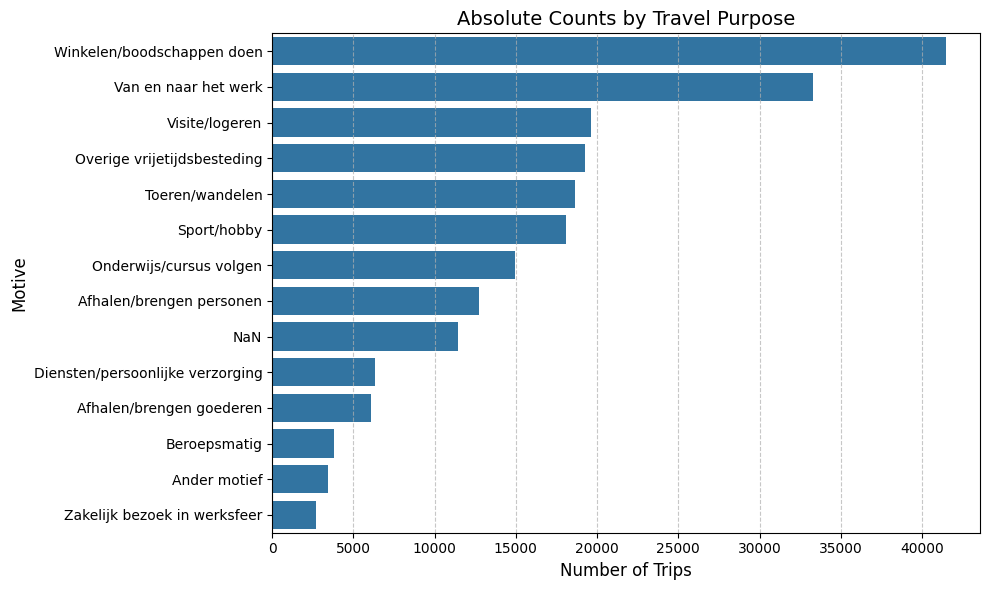

In [202]:
#Obtain Data
plot_motive = results["MotiefV"].sort_values('count', ascending = False)

#Def the plot
plt.figure(figsize=(10, 6))
sns.barplot(
    data = plot_motive, 
    x = 'count', 
    y = 'label', 
    #palette='magma'
)

#Labels
plt.title('Absolute Counts by Travel Purpose', fontsize=14)
plt.xlabel('Number of Trips', fontsize = 12)
plt.ylabel('Motive', fontsize = 12)
plt.grid(axis= 'x', linestyle = '--', alpha = 0.7)

plt.tight_layout()
plt.show()

Expectedly, the most common motive for travelling was reported to be "Winkelen/boodschappen doen" which means "Shopping". The second most common motive which is also the purpose of our analysis was reported to be "Van en naar het werk". It is translated to English as "To and From Work" and it counts for nearly 16% of all reported trips. It is important to mention that "NaN" motives are also a significant part of the survey as 5.38% of the participants did not mention their trip purpose.

Before analyzing the dataset further we need to make a working version which contains only the relevant analytical variables. We are going to select 20 variables required to describe a commuting trip. Others are dropped to ease the work and avoid any confusion. To do so we are going to perform the below steps:
1. Select relevant columns from the dataset and rename them to English. (Source for Dutch Names: odin_metadata.csv) 
2. Map the original dutch column names to English names.
3. Drop the remaining variables from the working dataset.   

In [207]:
rename_map = {
    # Identifiers
    "OP" : "new_id", #0- no ; 1= yes
    "OPID" : "person_id",
    "VerplID" : "trip_id",

    # Geography
    "WoGem" : "home_municipality",
    "VertGem" : "origin_municipality",
    "AankGem" : "dest_municipality",
    "VertPC" : "origin_postcode",
    "AankPC" : "dest_postcode",
    "BuurtAdam" : "amsterdam_neighborhood",

    # Trip characteristics
    "MotiefV" : "trip_purpose", # 1 = commuting ("Van en naar het werk")
    "Hvm" : "mode_detailed", #granular mode code
    "KHvm" : "mode_class", #1 = car , 4 = PT, 5 = bike
    "HvmRol" : "mode_role", # 1=driver/rider
    "Weekdag" : "weekday", # 2=Mon ... 6=Fri
    "Feestdag" : "is_holiday",
    "VertUur" : "departure_hour",
    "VertMin": "departure_minute",
    "Reisduur" : "travel_time_min",       # total door-to-door minutes
    "AfstV" : "distance_hm",           # trip distnace in hectometers — convert later imto km

    # Person characteristics
    "Leeftijd" : "age",
    "Geslacht" : "gender",                # 1=male, 2=female
    "HHBestInkG" : "income_decile",         # 1 (lowest) to 10 (highest)
    "OPRijbewijsAu" : "has_driving_license",   # 1=yes, 2=no
    "HHAuto" : "n_cars_household",

    # Survey weights
    "FactorV" : "weight_trip", #survey trip weight
    "FactorP" : "weight_person", #survey person weight
}

# Select and rename
work_data = odin_data[rename_map.keys()].rename(columns = rename_map).copy()

In [208]:
work_data.head(5)

,new_id,person_id,trip_id,home_municipality,origin_municipality,dest_municipality,origin_postcode,dest_postcode,amsterdam_neighborhood,trip_purpose,...,departure_minute,travel_time_min,distance_hm,age,gender,income_decile,has_driving_license,n_cars_household,weight_trip,weight_person
0,1.0,2.700008e+11,2.700008e+13,437.0,437.0,363.0,1191,1105,0,12.0,...,20.0,20.0,36.0,59.0,1.0,6.0,1.0,2.0,86521.379089,237.044874
1,0.0,2.700008e+11,2.700008e+13,437.0,363.0,437.0,1105,1191,0,12.0,...,0.0,15.0,36.0,59.0,1.0,6.0,1.0,2.0,86521.379089,237.044874
2,0.0,2.700008e+11,2.700008e+13,437.0,437.0,437.0,1191,1191,0,7.0,...,0.0,2.0,1.0,59.0,1.0,6.0,1.0,2.0,86521.379089,237.044874
3,0.0,2.700008e+11,2.700008e+13,437.0,437.0,437.0,1191,1191,0,7.0,...,45.0,2.0,1.0,59.0,1.0,6.0,1.0,2.0,86521.379089,237.044874
4,0.0,2.700008e+11,2.700008e+13,437.0,437.0,437.0,1191,1191,0,9.0,...,0.0,30.0,10.0,59.0,1.0,6.0,1.0,2.0,86521.379089,237.044874


In [219]:
#convert distance in hectometers to km
hm_to_km = 0.1   # converting coefficient
work_data["distance_km"] = (work_data.distance_hm * hm_to_km).round(3)

In [220]:
#Lets insert a flag when a trip was during peak hours
#AM peak: 07:00h - 09:00h ; PM peak: 17:00h - 19:00h (basd on the peak definition from Section 1.7)

# --- Peak hour definition ---
am_peak_start = 7
am_peak_end = 9
pm_peak_start = 17
pm_peak_end = 19

work_data["is_peak"] = (
    ((work_data.departure_hour.values >= am_peak_start) & (work_data.departure_hour.values < am_peak_end)) |
    ((work_data.departure_hour.values >= pm_peak_start) & (work_data.departure_hour.values < pm_peak_end))
).astype(np.int8)

NameError: name 'np' is not defined

In [ ]:
# --- Derived variable 3: chosen_mode string label ---
# Maps KHvm codes to analytical labels used in all downstream steps
MODE_LABEL_MAP = {
    KHVM_CAR_DRIVER : "car",
    KHVM_PT         : "pt",
    KHVM_BIKE       : "bike",
}
df_work["chosen_mode"] = (
    df_work["mode_class"]
    .map(MODE_LABEL_MAP)
    .astype("category")
)

In [218]:
print(f"Working sample shape: {work_data.shape}")
print(f"\nColumns retained ({len(work_data.columns)}):")
print(list(work_data.columns))
print(f"\nSample (5 rows):")
work_data.head(5)

Working sample shape: (211991, 27)

Columns retained (27):
['new_id', 'person_id', 'trip_id', 'home_municipality', 'origin_municipality', 'dest_municipality', 'origin_postcode', 'dest_postcode', 'amsterdam_neighborhood', 'trip_purpose', 'mode_detailed', 'mode_class', 'mode_role', 'weekday', 'is_holiday', 'departure_hour', 'departure_minute', 'travel_time_min', 'distance_hm', 'age', 'gender', 'income_decile', 'has_driving_license', 'n_cars_household', 'weight_trip', 'weight_person', 'distance_km']

Sample (5 rows):


,new_id,person_id,trip_id,home_municipality,origin_municipality,dest_municipality,origin_postcode,dest_postcode,amsterdam_neighborhood,trip_purpose,...,travel_time_min,distance_hm,age,gender,income_decile,has_driving_license,n_cars_household,weight_trip,weight_person,distance_km
0,1.0,2.700008e+11,2.700008e+13,437.0,437.0,363.0,1191,1105,0,12.0,...,20.0,36.0,59.0,1.0,6.0,1.0,2.0,86521.379089,237.044874,3.6
1,0.0,2.700008e+11,2.700008e+13,437.0,363.0,437.0,1105,1191,0,12.0,...,15.0,36.0,59.0,1.0,6.0,1.0,2.0,86521.379089,237.044874,3.6
2,0.0,2.700008e+11,2.700008e+13,437.0,437.0,437.0,1191,1191,0,7.0,...,2.0,1.0,59.0,1.0,6.0,1.0,2.0,86521.379089,237.044874,0.1
3,0.0,2.700008e+11,2.700008e+13,437.0,437.0,437.0,1191,1191,0,7.0,...,2.0,1.0,59.0,1.0,6.0,1.0,2.0,86521.379089,237.044874,0.1
4,0.0,2.700008e+11,2.700008e+13,437.0,437.0,437.0,1191,1191,0,9.0,...,30.0,10.0,59.0,1.0,6.0,1.0,2.0,86521.379089,237.044874,1.0


SyntaxError: invalid syntax (3023538684.py, line 4)

## Filtering the datasets and Scoping Down the Analysis


## Tidy Data Construction

## Data Cleaning

## Normalisation and feathering Construction